In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import skew, kurtosis

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import BayesianRidge
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [ ]:

np.random.seed(42)
N_DEVICES = 10
MIN_CYCLES = 150
MAX_CYCLES = 350

devices = []

for dev_id in range(N_DEVICES):

      R0 = np.random.uniform(8e-3, 12e-3)  # ohm

      total_cycles = np.random.randint(MIN_CYCLES, MAX_CYCLES)
      cycles = np.arange(total_cycles)


      frac = cycles / total_cycles   # 0..1

      r_inc = 0.05 * (frac**2.0 + 0.3 * frac)  # Fractional Increase of Rds(on)

      # 0.05% noise
      noise = np.random.normal(0, 0.0005, size=total_cycles)
      r_factor = 1.0 + r_inc + noise

      r_factor = np.clip(r_factor, 1.0, 1.07)

      Rds = R0 * r_factor  # actual RDS(on) vs cycle

      # Store per cycle
      for c, R in zip(cycles, Rds):
          devices.append({
              "device_id": dev_id,
              "cycle": c,
              "R0": R0,
              "Rds": R
          })

df_res = pd.DataFrame(devices)
df_res["R_increase_pct"] = (df_res["Rds"] - df_res["R0"]) / df_res["R0"] * 100.0
df_res.to_csv("synthetic_mosfet_rds_cycles.csv", index=False)
print("File saved: synthetic_mosfet_rds_cycles.csv")
df_res.head()


File saved: synthetic_mosfet_rds_cycles.csv


,device_id,cycle,R0,Rds,R_increase_pct
0,0,0,0.009498,0.009501,0.027187
1,0,1,0.009498,0.009498,0.000000
2,0,2,0.009498,0.009498,0.000000
3,0,3,0.009498,0.009510,0.126446
4,0,4,0.009498,0.009500,0.021428


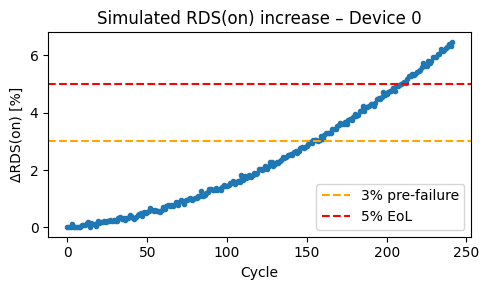

In [ ]:
example_dev = 0
sub = df_res[df_res["device_id"] == example_dev]

plt.figure(figsize=(5,3))
plt.plot(sub["cycle"], sub["R_increase_pct"], marker='.', linestyle='-')
plt.axhline(3, color='orange', linestyle='--', label='3% pre-failure')
plt.axhline(5, color='red', linestyle='--', label='5% EoL')
plt.xlabel("Cycle")
plt.ylabel("ΔRDS(on) [%]")
plt.title(f"Simulated RDS(on) increase – Device {example_dev}")
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:
N_SAMPLES_WF = 100  # samples in the 100 µs window

def simulate_waveform(Rds, target_current=5.0):
    """
    Very simple synthetic turn-on waveform:
    - current rises quickly then is ~constant
    - voltage = Rds * current + noise
    """
    t = np.linspace(0, 1, N_SAMPLES_WF)


    Id = target_current * (1 - np.exp(-10 * t))
    Id += np.random.normal(0, 0.05, size=N_SAMPLES_WF)
    Id = np.clip(Id, 0, None)


    Vds = Rds * Id

    # Adding a spike near the start to mimic switching transient
    spike_idx = np.random.randint(3, 10)
    Vds[spike_idx] *= np.random.uniform(1.1, 1.4)
    Vds += np.random.normal(0, 0.0005, size=N_SAMPLES_WF)

    return Vds, Id

# Table with waveforms
records = []

for _, row in df_res.iterrows():
    dev = int(row["device_id"])
    cyc = int(row["cycle"])
    Rds = float(row["Rds"])

    Vds, Id = simulate_waveform(Rds)

    records.append({
        "device_id": dev,
        "cycle": cyc,
        "R0": row["R0"],
        "Rds_true": Rds,
        "R_increase_pct": row["R_increase_pct"],
        "Vds_wave": Vds,
        "Id_wave": Id
    })

df = pd.DataFrame(records)
df.head()


,device_id,cycle,R0,Rds_true,R_increase_pct,Vds_wave,Id_wave
0,0,0,0.009498,0.009501,0.027187,"[0.0004124274958481575, 0.003604617742441413, ...","[0.07388409389688391, 0.34232739021578845, 0.8..."
1,0,1,0.009498,0.009498,0.000000,"[-0.0009051624975452677, 0.005499050713694347,...","[0.006177384797779117, 0.5780883602111022, 0.8..."
2,0,2,0.009498,0.009498,0.000000,"[0.00011064306086526628, 0.003982761110322323,...","[0.0, 0.3967062485397822, 0.8817736547908381, ..."
3,0,3,0.009498,0.009510,0.126446,"[-0.0003621232660291702, 0.003139374718358268,...","[0.0, 0.36797334418397976, 0.977673799388846, ..."
4,0,4,0.009498,0.009500,0.021428,"[0.001388320019719015, 0.00431033949975923, 0....","[0.13421728712116557, 0.43129823501482684, 0.8..."


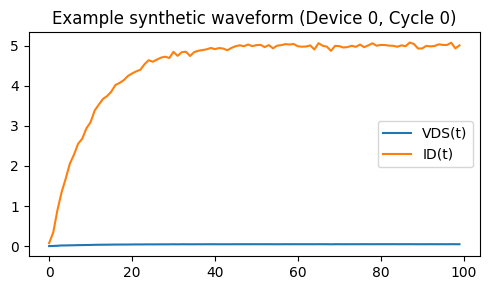

In [ ]:
ex = df[(df["device_id"]==0) & (df["cycle"]==0)].iloc[0]
plt.figure(figsize=(5,3))
plt.plot(ex["Vds_wave"], label="VDS(t)")
plt.plot(ex["Id_wave"], label="ID(t)")
plt.legend()
plt.title("Example synthetic waveform (Device 0, Cycle 0)")
plt.tight_layout()
plt.show()


In [ ]:
feature_rows = []

for _, row in df.iterrows():
    V = row["Vds_wave"]
    I = row["Id_wave"]

    # Avoid division by very small currents
    I_safe = np.where(I < 0.1, np.nan, I)
    R_inst = V / I_safe


    mask = ~np.isnan(R_inst)
    V = V[mask]
    I = I_safe[mask]
    R_inst = R_inst[mask]


    if len(R_inst) < 10:
        continue
    q10 = np.quantile(R_inst, 0.10)
    q90 = np.quantile(R_inst, 0.90)
    keep = (R_inst >= q10) & (R_inst <= q90)
    V = V[keep]
    I = I[keep]
    R_inst = R_inst[keep]

    def safe_stats(x):
        return {
            "mean": np.mean(x),
            "std": np.std(x),
            "skew": skew(x),
            "kurt": kurtosis(x)
        }

    sV = safe_stats(V)
    sI = safe_stats(I)
    sR = safe_stats(R_inst)

    feature_rows.append({
        "device_id": row["device_id"],
        "cycle": row["cycle"],
        "R0": row["R0"],
        "Rds_true": row["Rds_true"],
        "R_increase_pct": row["R_increase_pct"],

        "V_mean": sV["mean"],
        "V_std": sV["std"],
        "V_skew": sV["skew"],
        "V_kurt": sV["kurt"],

        "I_mean": sI["mean"],
        "I_std": sI["std"],
        "I_skew": sI["skew"],
        "I_kurt": sI["kurt"],

        "R_mean": sR["mean"],
        "R_std": sR["std"],
        "R_skew": sR["skew"],
        "R_kurt": sR["kurt"],
    })

df_feat = pd.DataFrame(feature_rows)
df_feat.head()


,device_id,cycle,R0,Rds_true,R_increase_pct,V_mean,V_std,V_skew,V_kurt,I_mean,I_std,I_skew,I_kurt,R_mean,R_std,R_skew,R_kurt
0,0,0,0.009498,0.009501,0.027187,0.044696,0.005672,-2.453829,5.804031,4.695886,0.594821,-2.500647,6.006175,0.009519,0.000074,-0.290544,-0.966147
1,0,1,0.009498,0.009498,0.000000,0.044157,0.007317,-3.226713,11.344958,4.638036,0.767605,-3.234358,11.367296,0.009520,0.000072,-0.087585,-0.859064
2,0,2,0.009498,0.009498,0.000000,0.044989,0.005325,-2.648179,6.837473,4.732140,0.550462,-2.687289,6.983412,0.009504,0.000078,0.211380,-0.853277
3,0,3,0.009498,0.009510,0.126446,0.044474,0.006908,-3.033504,9.557498,4.669589,0.723196,-3.036571,9.600689,0.009523,0.000075,0.003133,-0.999618
4,0,4,0.009498,0.009500,0.021428,0.044968,0.005276,-2.942328,9.012503,4.729116,0.556903,-2.996651,9.177291,0.009510,0.000080,0.277620,-0.601309


In [ ]:

df_feat = df_feat[df_feat["R_increase_pct"] <= 7.0].copy()


df_feat["SoH_label"] = (df_feat["R_increase_pct"] >= 3.0).astype(int)

df_feat["SoH_label"].value_counts()


,count
SoH_label,
0,1572
1,885


In [ ]:
all_devices = df_feat["device_id"].unique()
np.random.shuffle(all_devices)

train_devs = all_devices[:7]
test_devs  = all_devices[7:]

train = df_feat[df_feat["device_id"].isin(train_devs)]
test  = df_feat[df_feat["device_id"].isin(test_devs)]

feature_cols = [
    "V_mean","V_std","V_skew","V_kurt",
    "I_mean","I_std","I_skew","I_kurt",
    "R_mean","R_std","R_skew","R_kurt"
]

X_train = train[feature_cols].values
y_train = train["SoH_label"].values

X_test  = test[feature_cols].values
y_test  = test["SoH_label"].values

len(train), len(test), train["device_id"].unique(), test["device_id"].unique()


(1705, 752, array([0, 1, 2, 5, 6, 7, 8]), array([3, 4, 9]))

In [ ]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42
)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print("Random Forest SoH accuracy on unseen devices:", acc)
print()
print(classification_report(y_test, y_pred, target_names=["Healthy (0)", "Pre-failure (1)"]))

print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))


Random Forest SoH accuracy on unseen devices: 0.6436170212765957

                 precision    recall  f1-score   support

    Healthy (0)       1.00      0.44      0.61       481
Pre-failure (1)       0.50      1.00      0.67       271

       accuracy                           0.64       752
      macro avg       0.75      0.72      0.64       752
   weighted avg       0.82      0.64      0.63       752

Confusion matrix:
 [[213 268]
 [  0 271]]


In [ ]:

dev_for_rul = int(test["device_id"].unique()[0])
dev_data = df_feat[df_feat["device_id"] == dev_for_rul].sort_values("cycle")


eol_mask = dev_data["R_increase_pct"] >= 5.0
true_eol_cycle = dev_data[eol_mask]["cycle"].iloc[0]


pf_mask = dev_data["R_increase_pct"] >= 3.0
first_pf_cycle = dev_data[pf_mask]["cycle"].iloc[0]

print("Device:", dev_for_rul)
print("Pre-failure trigger cycle (3%):", first_pf_cycle)
print("True EoL cycle (5%):", true_eol_cycle)
print("True RUL at trigger:", true_eol_cycle - first_pf_cycle, "cycles")

# Take 30 points after trigger
train_segment = dev_data[dev_data["cycle"] >= first_pf_cycle].head(30)
x_train = train_segment["cycle"].values.reshape(-1,1)
y_train = train_segment["Rds_true"].values


brr = BayesianRidge()
brr.fit(x_train, y_train)


all_cycles = dev_data["cycle"].values.reshape(-1,1)
y_pred = brr.predict(all_cycles)


R0_dev = dev_data["R0"].iloc[0]
eol_level = R0_dev * 1.05

pred_eol_idx = np.where(y_pred >= eol_level)[0]
if len(pred_eol_idx) > 0:
    pred_eol_cycle = int(all_cycles[pred_eol_idx[0], 0])
else:
    pred_eol_cycle = int(all_cycles[-1,0])

print("Predicted EoL cycle:", pred_eol_cycle)
print("Predicted RUL at trigger:", pred_eol_cycle - first_pf_cycle, "cycles")
print("RUL error (pred - true):", (pred_eol_cycle - first_pf_cycle) - (true_eol_cycle - first_pf_cycle))


Device: 3
Pre-failure trigger cycle (3%): 200
True EoL cycle (5%): 271
True RUL at trigger: 71 cycles
Predicted EoL cycle: 273
Predicted RUL at trigger: 73 cycles
RUL error (pred - true): 2


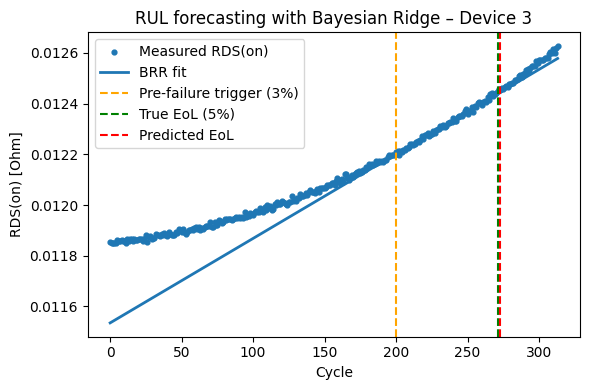

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(dev_data["cycle"], dev_data["Rds_true"], label="Measured RDS(on)", s=12)
plt.plot(dev_data["cycle"], y_pred, label="BRR fit", linewidth=2)

plt.axvline(first_pf_cycle, color='orange', linestyle='--', label="Pre-failure trigger (3%)")
plt.axvline(true_eol_cycle,  color='green', linestyle='--', label="True EoL (5%)")
plt.axvline(pred_eol_cycle,  color='red', linestyle='--', label="Predicted EoL")

plt.xlabel("Cycle")
plt.ylabel("RDS(on) [Ohm]")
plt.title(f"RUL forecasting with Bayesian Ridge – Device {dev_for_rul}")
plt.legend()
plt.tight_layout()
plt.show()